# Chapter 4: introduction to neural learning: gradient descent

Haikal Ali TK-46-GAB 1103223071

## In this chapter

- Do neural networks make accurate predictions?
- Why measure error?
- Hot and cold learning
- Calculating both direction and amount from error
- Gradient descent
- Learning is just reducing error
- Derivatives and how to use them to learn
- Divergence and alpha

## Predict, compare, and learn

Pada chapter 3, konsep **predict, compare, learn** sudah diperkenalkan, dan bagian **predict** dibahas lebih dalam. Dalam proses tersebut, neural network dipahami melalui node, weights, bentuk dataset yang masuk ke network, dan cara network membuat prediction.

Pertanyaan berikutnya adalah: bagaimana cara menentukan nilai weight agar network dapat membuat prediction yang akurat?

Chapter ini membahas dua langkah berikutnya, yaitu **compare** dan **learn**.

## Compare

Compare memberi ukuran seberapa jauh prediction meleset.

Setelah prediction dibuat, langkah berikutnya adalah mengevaluasi seberapa baik hasilnya. Cara mengukur error adalah salah satu bagian penting dalam deep learning.

Error perlu memiliki sifat tertentu. Misalnya, error selalu bernilai positif. Jika seorang pemanah meleset 1 inci terlalu rendah atau 1 inci terlalu tinggi, error-nya tetap 1 inci. Dalam langkah compare pada neural network, sifat seperti ini perlu diperhatikan saat mengukur error.

Pada chapter ini, cara pengukuran error yang digunakan adalah **mean squared error**. Ini hanya salah satu dari banyak cara untuk mengevaluasi akurasi neural network.

Compare memberi sinyal seperti “hot or cold”. Dari sebuah prediction, error akan menunjukkan apakah miss-nya besar, kecil, atau prediction sudah tepat. Namun, error belum memberi tahu alasan miss, arah miss, atau hal yang harus dilakukan untuk memperbaiki miss tersebut. Bagian itu ditangani pada langkah **learn**.

## Learn

Learning memberi tahu setiap weight bagaimana weight tersebut dapat berubah untuk mengurangi error.

Learning berhubungan dengan **error attribution**, yaitu mencari tahu bagaimana setiap weight berperan dalam menciptakan error. Pada chapter ini, metode utama yang dibahas adalah **gradient descent**.

Hasil akhirnya adalah menghitung sebuah angka untuk setiap weight. Angka tersebut menunjukkan apakah weight perlu dinaikkan atau diturunkan agar error berkurang. Setelah itu, weight dipindahkan sesuai angka tersebut.

## Compare: Does your network make good predictions?

Kode berikut mengukur error dari prediction. Hasilnya adalah `0.3025`.

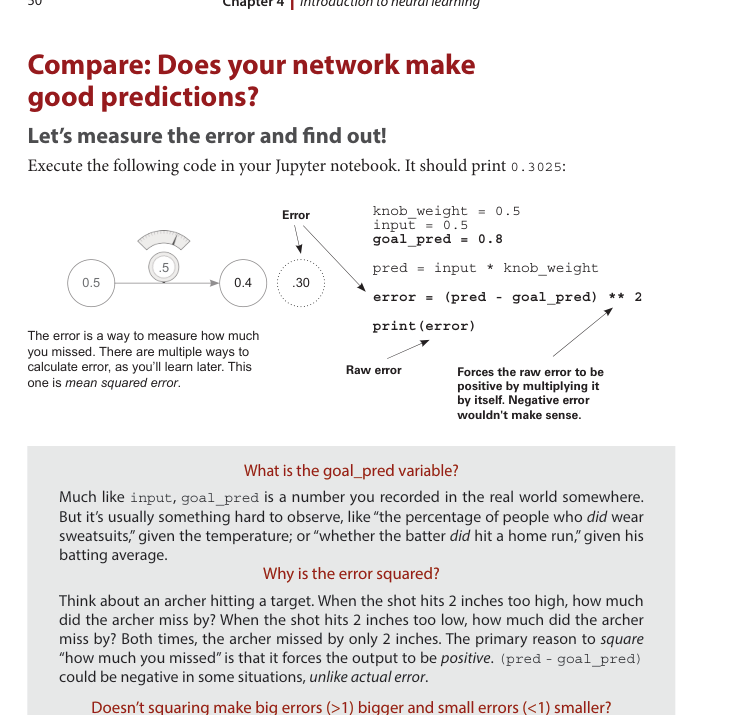

In [1]:
knob_weight = 0.5
input = 0.5
goal_pred = 0.8

pred = input * knob_weight
error = (pred - goal_pred) ** 2

print(error)

0.30250000000000005


`goal_pred` adalah angka yang dicatat dari dunia nyata, sama seperti `input`. Bedanya, `goal_pred` biasanya lebih sulit diamati secara langsung. Contohnya adalah persentase orang yang benar-benar memakai sweatsuits berdasarkan temperatur, atau apakah seorang batter benar-benar melakukan home run berdasarkan batting average.

Error dikuadratkan agar hasilnya positif. Nilai `(pred - goal_pred)` dapat bernilai negatif, padahal error tidak seharusnya saling menghapus. Squaring juga membuat error besar menjadi lebih besar dan error kecil menjadi lebih kecil. Dengan begitu, network lebih memperhatikan error besar dan tidak terlalu memikirkan error kecil.

## Why measure error?

Mengukur error menyederhanakan masalah.

Tujuan training neural network adalah membuat prediction yang benar. Network berguna ketika input mudah dihitung, seperti harga saham hari ini, dan output yang ingin diprediksi sulit dihitung, seperti harga saham besok.

Mengubah `knob_weight` agar network memprediksi `goal_prediction` dengan benar sedikit lebih rumit dibanding mengubah `knob_weight` agar `error == 0`. Keduanya sebenarnya menyatakan hal yang sama, tetapi membuat error menjadi 0 terasa lebih langsung.

Cara berbeda dalam mengukur error akan memprioritaskan error secara berbeda. Squared error memperbesar pure error yang besar dan mengecilkan pure error yang kecil. Jika pure error adalah 10, squared error menjadi 100. Jika pure error adalah 0.01, squared error menjadi 0.0001.

Error perlu selalu positif karena nantinya akan ada banyak pasangan `input -> goal_prediction`. Jika error bisa positif dan negatif, error dapat saling menghapus ketika dirata-ratakan. Misalnya error 1000 dan -1000 memiliki rata-rata 0, padahal prediction meleset besar pada dua data tersebut.

## What’s the simplest form of neural learning?

Bentuk learning paling sederhana adalah **hot and cold learning**.

Learning berarti menyesuaikan `knob_weight` naik atau turun agar error berkurang. Jika proses ini dilakukan terus-menerus sampai error menjadi 0, maka network sudah selesai belajar.

Untuk mengetahui apakah weight perlu dinaikkan atau diturunkan, cara paling sederhana adalah mencoba keduanya. Weight dinaikkan sedikit, error dihitung. Weight diturunkan sedikit, error dihitung. Arah dengan error yang lebih kecil dipakai untuk memperbarui weight.

## Hot and cold learning

Hot and cold learning berarti menggoyangkan weights untuk melihat arah mana yang paling mengurangi error, memindahkan weights ke arah tersebut, lalu mengulanginya sampai error menuju 0.

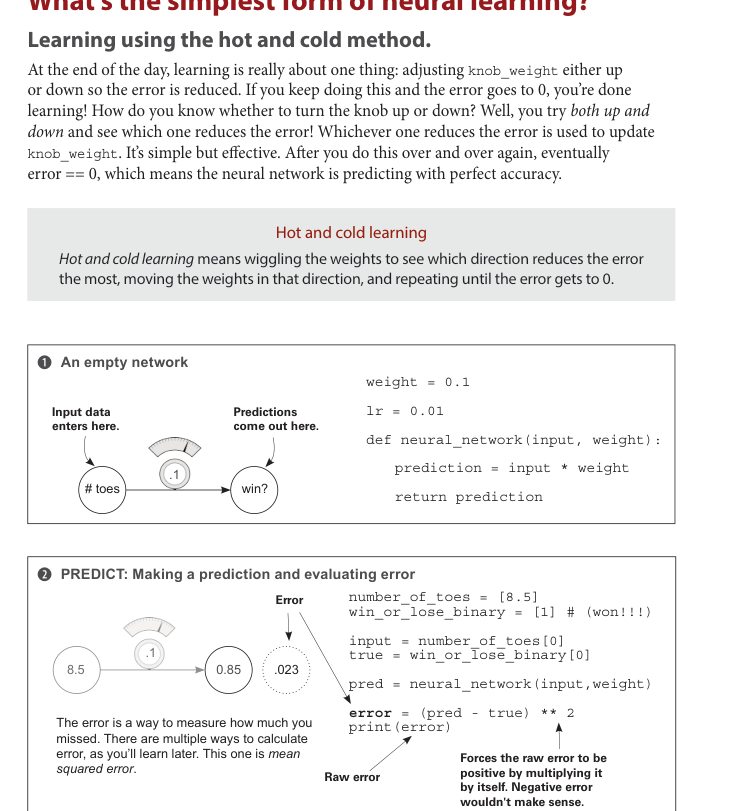

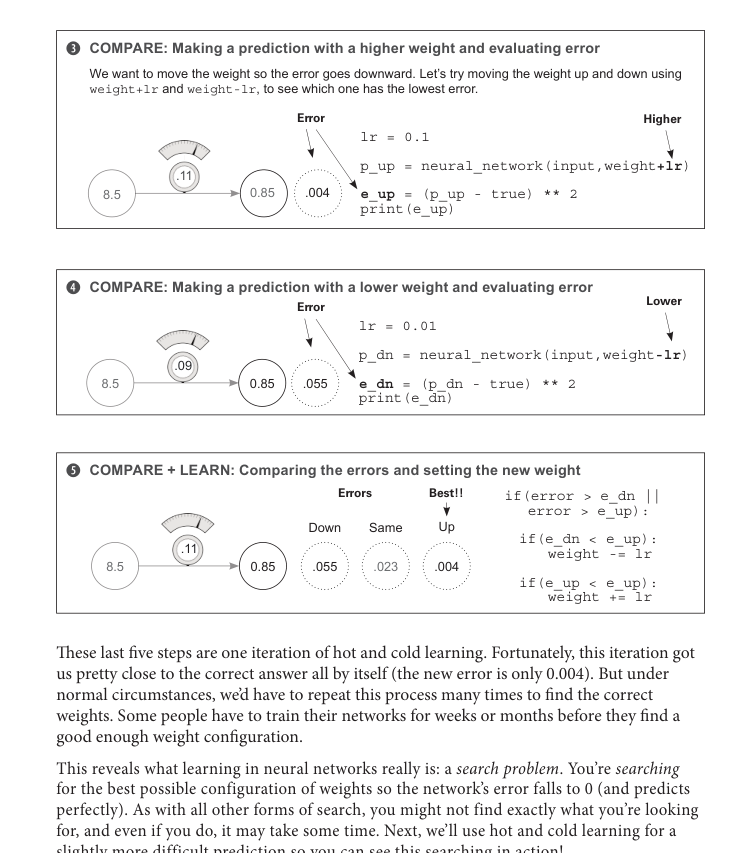

Satu iterasi hot and cold learning terdiri dari prediction, membandingkan error ketika weight dinaikkan dan diturunkan, lalu memperbarui weight berdasarkan error yang lebih kecil.

Learning dalam neural networks dapat dilihat sebagai search problem. Network mencari konfigurasi weights terbaik agar error turun menuju 0 dan prediction menjadi tepat.

In [2]:
weight = 0.1
lr = 0.01

def neural_network(input, weight):
  prediction = input * weight
  return prediction

number_of_toes = [8.5]
win_or_lose_binary = [1]

input = number_of_toes[0]
true = win_or_lose_binary[0]

pred = neural_network(input, weight)
error = (pred - true) ** 2

p_up = neural_network(input, weight + lr)
e_up = (p_up - true) ** 2

p_dn = neural_network(input, weight - lr)
e_dn = (p_dn - true) ** 2

if error > e_dn or error > e_up:
  if e_dn < e_up:
    weight -= lr

  if e_up < e_dn:
    weight += lr

print("Prediction:", pred)
print("Error:", error)
print("Error up:", e_up)
print("Error down:", e_dn)
print("New weight:", weight)

Prediction: 0.8500000000000001
Error: 0.022499999999999975
Error up: 0.004224999999999993
Error down: 0.05522499999999994
New weight: 0.11


Kode berikut mencoba memprediksi `0.8` menggunakan hot and cold learning.

In [3]:
weight = 0.5
input = 0.5
goal_prediction = 0.8
step_amount = 0.001

for iteration in range(1101):
  prediction = input * weight
  error = (prediction - goal_prediction) ** 2

  if iteration < 5 or iteration > 1095:
    print("Error:" + str(error) + " Prediction:" + str(prediction))

  if iteration == 5:
    print("...")

  up_prediction = input * (weight + step_amount)
  up_error = (goal_prediction - up_prediction) ** 2

  down_prediction = input * (weight - step_amount)
  down_error = (goal_prediction - down_prediction) ** 2

  if down_error < up_error:
    weight = weight - step_amount

  if down_error > up_error:
    weight = weight + step_amount

Error:0.30250000000000005 Prediction:0.25
Error:0.3019502500000001 Prediction:0.2505
Error:0.30140100000000003 Prediction:0.251
Error:0.30085225 Prediction:0.2515
Error:0.30030400000000007 Prediction:0.252
...
Error:4.000000000130569e-06 Prediction:0.7979999999999674
Error:2.2500000000980924e-06 Prediction:0.7984999999999673
Error:1.000000000065505e-06 Prediction:0.7989999999999673
Error:2.5000000003280753e-07 Prediction:0.7994999999999672
Error:1.0799505792475652e-27 Prediction:0.7999999999999672


## Characteristics of hot and cold learning

Hot and cold learning sederhana. Setelah membuat prediction, network membuat dua prediction tambahan: satu dengan weight sedikit lebih tinggi, satu dengan weight sedikit lebih rendah. Weight kemudian dipindahkan ke arah yang menghasilkan error lebih kecil.

Jumlah iterasi `1101` digunakan karena pada contoh ini network mencapai `0.8` setelah jumlah iterasi tersebut. Jika iterasi dilanjutkan, weight dapat bergoyang di sekitar nilai target.

Masalah pertama: metode ini tidak efisien karena perlu melakukan prediction beberapa kali untuk satu update weight.

Masalah kedua: kadang mustahil memprediksi target secara tepat. Dengan `step_amount` tetap, jika weight sempurna tidak berada tepat sejauh `n * step_amount`, network akan overshoot dan mulai bolak-balik di sekitar `goal_prediction`.

Kode berikut menunjukkan kasus ketika `step_amount` terlalu besar.

In [4]:
weight = 0.5
input = 0.5
goal_prediction = 0.8
step_amount = 10

for iteration in range(10):
  prediction = input * weight
  error = (prediction - goal_prediction) ** 2

  print("Error:" + str(error) + " Prediction:" + str(prediction))

  up_prediction = input * (weight + step_amount)
  up_error = (goal_prediction - up_prediction) ** 2

  down_prediction = input * (weight - step_amount)
  down_error = (goal_prediction - down_prediction) ** 2

  if down_error < up_error:
    weight = weight - step_amount

  if down_error > up_error:
    weight = weight + step_amount

Error:0.30250000000000005 Prediction:0.25
Error:19.802500000000002 Prediction:5.25
Error:0.30250000000000005 Prediction:0.25
Error:19.802500000000002 Prediction:5.25
Error:0.30250000000000005 Prediction:0.25
Error:19.802500000000002 Prediction:5.25
Error:0.30250000000000005 Prediction:0.25
Error:19.802500000000002 Prediction:5.25
Error:0.30250000000000005 Prediction:0.25
Error:19.802500000000002 Prediction:5.25


Masalah utamanya adalah meskipun arah perubahan weight diketahui, jumlah perubahan yang benar belum diketahui. `step_amount` dipilih secara tetap dan tidak berhubungan langsung dengan error. Karena itu, hot and cold learning tidak efisien dan nilai `step_amount` yang sembarang dapat mencegah network mempelajari weight yang tepat.

## Calculating both direction and amount from error

Gradient descent menghitung arah dan jumlah perubahan weight dari error.

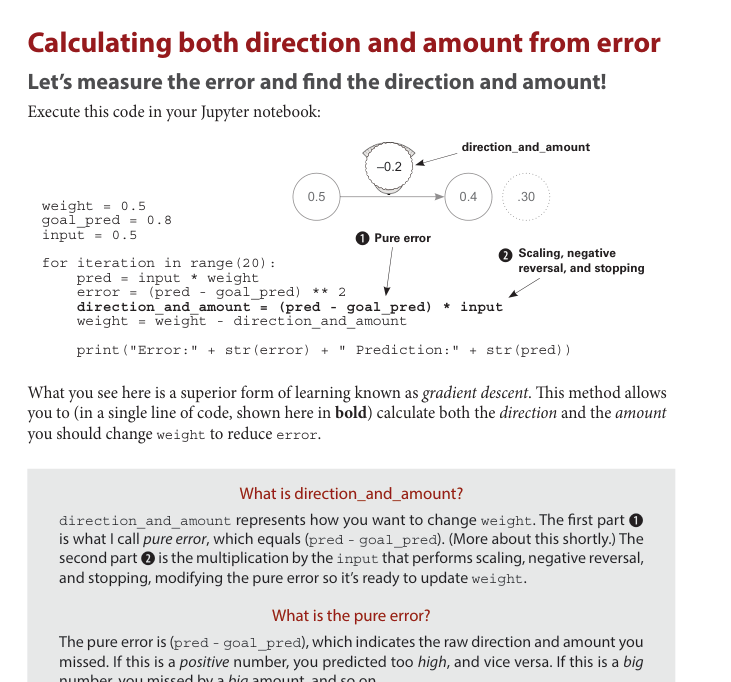

In [5]:
weight = 0.5
goal_pred = 0.8
input = 0.5

for iteration in range(20):
  pred = input * weight
  error = (pred - goal_pred) ** 2
  direction_and_amount = (pred - goal_pred) * input
  weight = weight - direction_and_amount

  print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.30250000000000005 Prediction:0.25
Error:0.17015625000000004 Prediction:0.3875
Error:0.095712890625 Prediction:0.49062500000000003
Error:0.05383850097656251 Prediction:0.56796875
Error:0.03028415679931642 Prediction:0.6259765625
Error:0.0170348381996155 Prediction:0.669482421875
Error:0.00958209648728372 Prediction:0.70211181640625
Error:0.005389929274097089 Prediction:0.7265838623046875
Error:0.0030318352166796153 Prediction:0.7449378967285156
Error:0.0017054073093822882 Prediction:0.7587034225463867
Error:0.0009592916115275371 Prediction:0.76902756690979
Error:0.0005396015314842384 Prediction:0.7767706751823426
Error:0.000303525861459885 Prediction:0.7825780063867569
Error:0.00017073329707118678 Prediction:0.7869335047900676
Error:9.603747960254256e-05 Prediction:0.7902001285925507
Error:5.402108227642978e-05 Prediction:0.7926500964444131
Error:3.038685878049206e-05 Prediction:0.7944875723333098
Error:1.7092608064027242e-05 Prediction:0.7958656792499823
Error:9.614592036015323

`direction_and_amount` menunjukkan bagaimana weight perlu diubah. Bagian pertama adalah **pure error**, yaitu `(pred - goal_pred)`. Bagian kedua adalah perkalian dengan `input`, yang melakukan scaling, negative reversal, dan stopping.

Pure error menunjukkan arah dan jumlah raw miss. Jika nilainya positif, prediction terlalu tinggi. Jika nilainya negatif, prediction terlalu rendah. Jika nilainya besar, miss-nya juga besar.

**Stopping** terjadi ketika `input` bernilai 0. Jika `input` adalah 0, maka `direction_and_amount` juga menjadi 0. Weight tidak perlu berubah karena semua nilai weight menghasilkan prediction yang sama, yaitu 0.

**Negative reversal** terjadi ketika `input` negatif. Biasanya, menaikkan weight membuat prediction naik. Namun jika input negatif, menaikkan weight justru membuat prediction turun. Perkalian pure error dengan input membalik tanda `direction_and_amount` saat input negatif, sehingga weight tetap bergerak ke arah yang benar.

**Scaling** berarti jika input besar, update weight juga menjadi besar. Efek ini dapat berguna, tetapi juga dapat menjadi tidak terkendali. Nanti alpha digunakan untuk menangani hal tersebut.

## One iteration of gradient descent

Bagian ini melakukan satu weight update pada satu pasangan training example, yaitu `input -> true`.

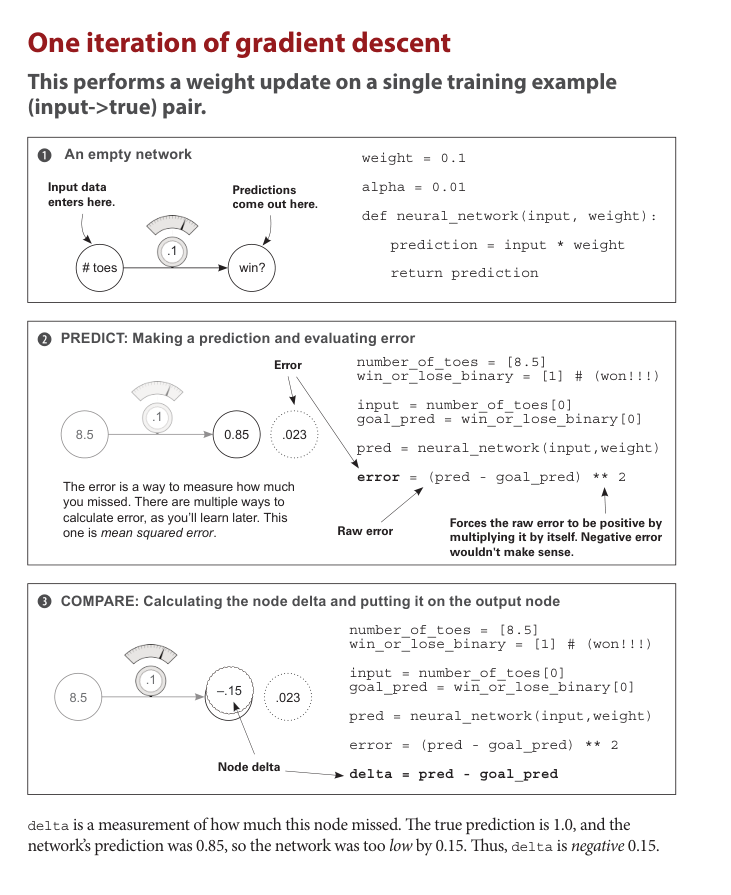

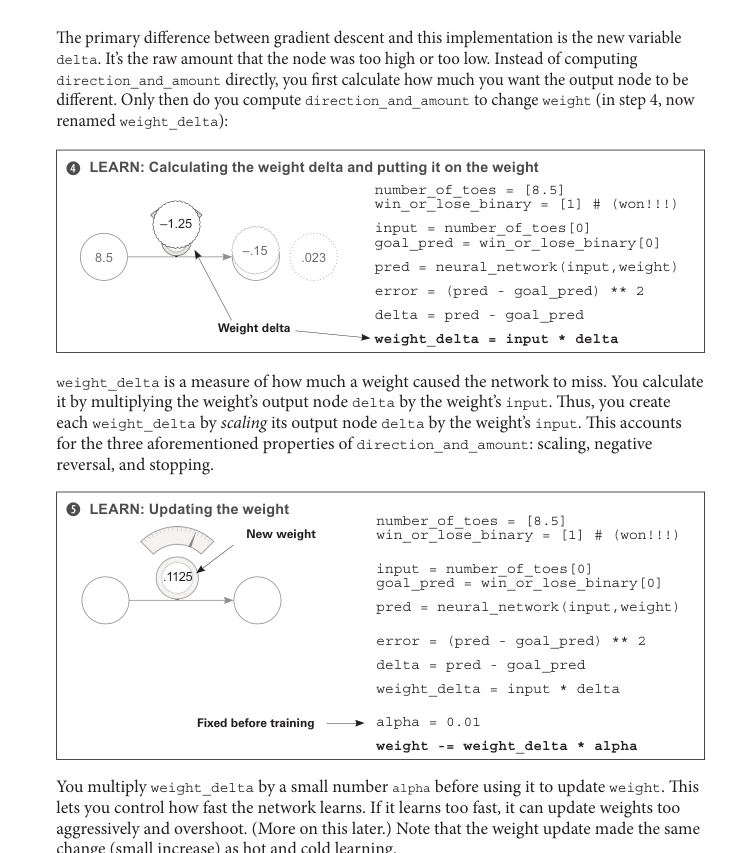

Perbedaan utama implementasi ini adalah adanya variabel `delta`. `delta` adalah jumlah raw seberapa tinggi atau rendah output node meleset.

Setelah `delta` dihitung, `weight_delta` dihitung dengan mengalikan `input` dengan `delta`. `weight_delta` mengukur seberapa besar sebuah weight menyebabkan network meleset.

Sebelum dipakai untuk memperbarui weight, `weight_delta` dikalikan dengan `alpha`. `alpha` mengontrol seberapa cepat network belajar. Jika terlalu cepat, weight dapat berubah terlalu agresif dan overshoot.

In [6]:
weight = 0.1
alpha = 0.01

def neural_network(input, weight):
  prediction = input * weight
  return prediction

number_of_toes = [8.5]
win_or_lose_binary = [1]

input = number_of_toes[0]
goal_pred = win_or_lose_binary[0]

pred = neural_network(input, weight)
error = (pred - goal_pred) ** 2
delta = pred - goal_pred
weight_delta = input * delta

weight -= weight_delta * alpha

print("Prediction:", pred)
print("Error:", error)
print("Delta:", delta)
print("Weight delta:", weight_delta)
print("New weight:", weight)

Prediction: 0.8500000000000001
Error: 0.022499999999999975
Delta: -0.1499999999999999
Weight delta: -1.2749999999999992
New weight: 0.11275


## Learning is just reducing error

Learning adalah proses mengubah weight untuk mengurangi error.

Kode berikut menggabungkan bagian sebelumnya.

In [7]:
weight, goal_pred, input = (0.0, 0.8, 0.5)

for iteration in range(4):
  pred = input * weight
  error = (pred - goal_pred) ** 2
  delta = pred - goal_pred
  weight_delta = delta * input
  weight = weight - weight_delta

  print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.6400000000000001 Prediction:0.0
Error:0.3600000000000001 Prediction:0.2
Error:0.2025 Prediction:0.35000000000000003
Error:0.11390625000000001 Prediction:0.4625


Rumus prediction dan error dapat digabungkan menjadi:

`error = ((input * weight) - goal_pred) ** 2`

Jika `input` dan `goal_pred` tetap, maka ada hubungan tepat antara `error` dan `weight`.

Dalam contoh:

`error = ((0.5 * weight) - 0.8) ** 2`

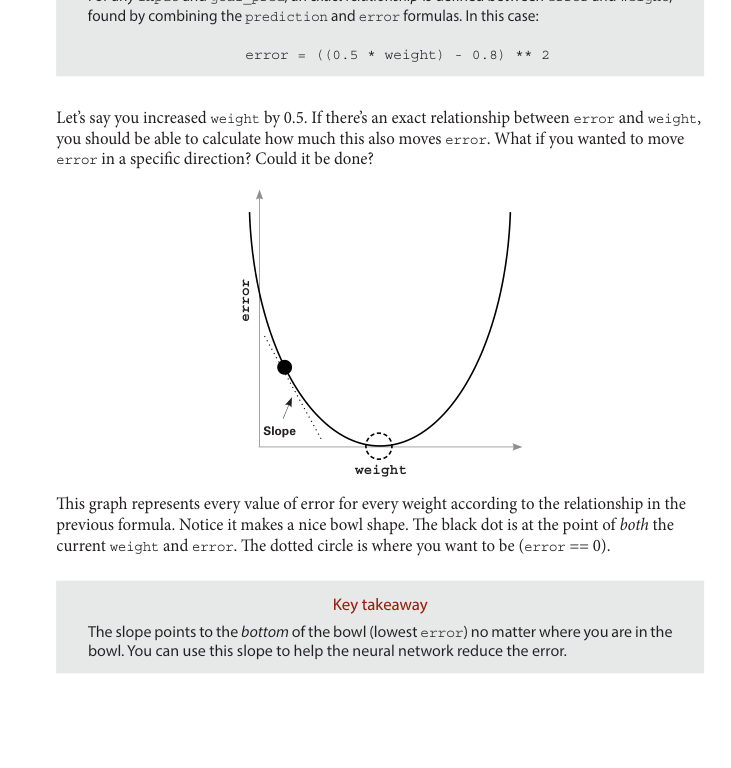

Grafik hubungan error dan weight membentuk kurva seperti mangkuk. Titik terendah adalah tempat `error == 0`.

Slope mengarah ke dasar mangkuk, yaitu error paling rendah. Slope ini dapat digunakan untuk membantu neural network mengurangi error.

## Let’s watch several steps of learning

Kode berikut menunjukkan beberapa langkah learning.

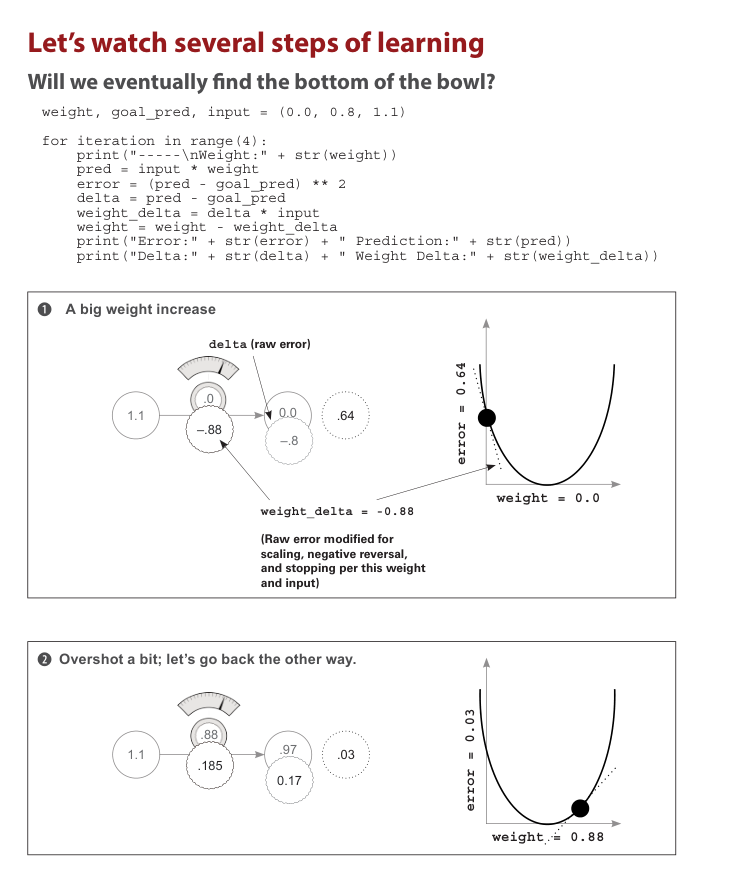

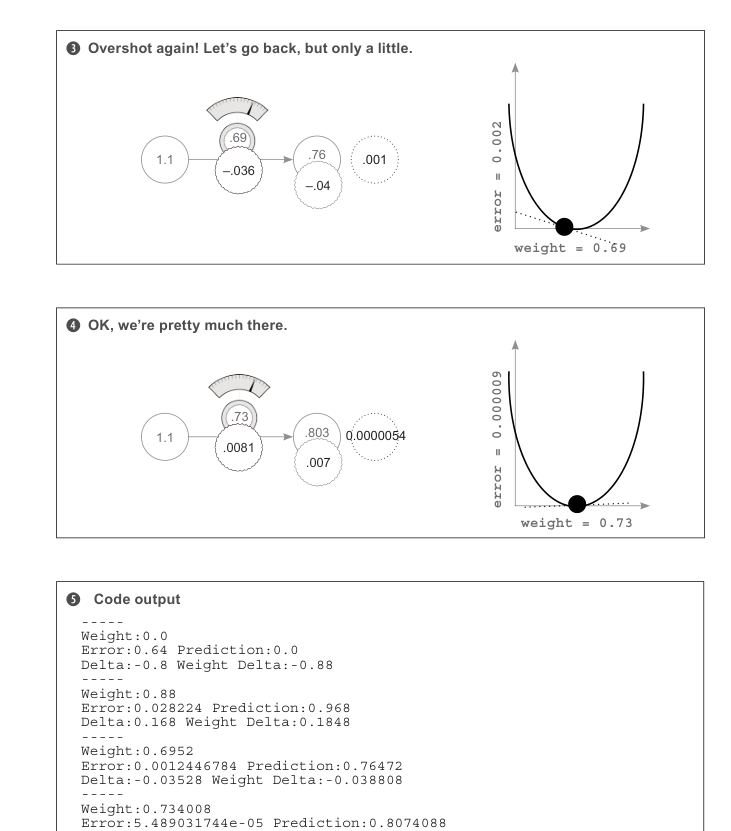

In [8]:
weight, goal_pred, input = (0.0, 0.8, 1.1)

for iteration in range(4):
  print("-----")
  print("Weight:" + str(weight))

  pred = input * weight
  error = (pred - goal_pred) ** 2
  delta = pred - goal_pred
  weight_delta = delta * input
  weight = weight - weight_delta

  print("Error:" + str(error) + " Prediction:" + str(pred))
  print("Delta:" + str(delta) + " Weight Delta:" + str(weight_delta))

-----
Weight:0.0
Error:0.6400000000000001 Prediction:0.0
Delta:-0.8 Weight Delta:-0.8800000000000001
-----
Weight:0.8800000000000001
Error:0.02822400000000005 Prediction:0.9680000000000002
Delta:0.16800000000000015 Weight Delta:0.1848000000000002
-----
Weight:0.6951999999999999
Error:0.0012446784000000064 Prediction:0.76472
Delta:-0.03528000000000009 Weight Delta:-0.0388080000000001
-----
Weight:0.734008
Error:5.4890317439999896e-05 Prediction:0.8074088
Delta:0.007408799999999993 Weight Delta:0.008149679999999992


Langkah pertama menaikkan weight cukup besar. Setelah itu, weight dapat overshoot dan bergerak kembali ke arah sebaliknya. Semakin dekat ke target, perubahan weight menjadi lebih kecil.

## Why does this work? What is weight_delta, really?

Sebuah function menerima angka sebagai input dan menghasilkan angka lain sebagai output. Function mendefinisikan hubungan antara input dan output.

Contoh:

`def my_function(x): return x * 2`

Kemampuan untuk mempelajari sebuah function sangat kuat karena memungkinkan angka seperti pixel gambar diubah menjadi angka lain seperti probabilitas gambar tersebut berisi kucing.

Function memiliki bagian yang dapat diubah. Pada `my_function`, angka `2` mengontrol hubungan antara input dan output. Pada neural network, formula error adalah:

`error = ((input * weight) - goal_pred) ** 2`

Banyak bagian berperan dalam menghitung error, seperti `goal_pred`, `input`, pangkat 2, `weight`, dan operasi aljabar. Namun, tidak semua bagian boleh diubah. `goal_pred` tidak diubah karena itu berarti mengubah target. `input` tidak diubah karena itu berarti mengubah data dunia nyata. Cara menghitung error juga tidak diubah karena error harus tetap menjadi ukuran miss yang bermakna.

Bagian yang tersisa untuk diubah adalah `weight`. Mengubah weight membuat function menyesuaikan diri dengan pola dalam data.

In [9]:
weight = 0.5
goal_pred = 0.8
input = 0.5

for iteration in range(20):
  pred = input * weight
  error = (pred - goal_pred) ** 2
  direction_and_amount = (pred - goal_pred) * input
  weight = weight - direction_and_amount

  print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.30250000000000005 Prediction:0.25
Error:0.17015625000000004 Prediction:0.3875
Error:0.095712890625 Prediction:0.49062500000000003
Error:0.05383850097656251 Prediction:0.56796875
Error:0.03028415679931642 Prediction:0.6259765625
Error:0.0170348381996155 Prediction:0.669482421875
Error:0.00958209648728372 Prediction:0.70211181640625
Error:0.005389929274097089 Prediction:0.7265838623046875
Error:0.0030318352166796153 Prediction:0.7449378967285156
Error:0.0017054073093822882 Prediction:0.7587034225463867
Error:0.0009592916115275371 Prediction:0.76902756690979
Error:0.0005396015314842384 Prediction:0.7767706751823426
Error:0.000303525861459885 Prediction:0.7825780063867569
Error:0.00017073329707118678 Prediction:0.7869335047900676
Error:9.603747960254256e-05 Prediction:0.7902001285925507
Error:5.402108227642978e-05 Prediction:0.7926500964444131
Error:3.038685878049206e-05 Prediction:0.7944875723333098
Error:1.7092608064027242e-05 Prediction:0.7958656792499823
Error:9.614592036015323

Learning adalah tentang mengubah prediction function secara otomatis agar prediction menjadi baik dan error turun menuju 0.

## Tunnel vision on one concept

Konsep utama: learning adalah menyesuaikan weight untuk mengurangi error menjadi 0.

Untuk memahami hubungan antara weight dan error, perlu dipahami bagaimana perubahan pada satu variabel memengaruhi variabel lain. Hal yang dicari adalah sensitivitas antara weight dan error. Sensitivitas adalah arah dan jumlah perubahan.

Hot and cold learning mempelajari hubungan weight dan error secara eksperimental dengan menggoyangkan weight naik dan turun, lalu mengamati perubahan error.

Formula berikut mendefinisikan hubungan tepat antara error dan weight:

`error = ((input * weight) - goal_pred) ** 2`

Formula ini dapat digunakan untuk mengetahui bagaimana mengubah weight agar error bergerak ke arah tertentu.

## A box with rods poking out of it

Derivative dapat dipahami sebagai jawaban dari pertanyaan: ketika satu bagian digerakkan, seberapa jauh bagian lain ikut bergerak?

Bayangkan sebuah kotak dengan dua batang. Jika batang biru didorong masuk 1 inci dan batang merah ikut bergerak masuk 2 inci, maka ada hubungan antara keduanya. Hubungan tersebut dapat ditulis:

`red_length = blue_length * 2`

Derivative untuk “seberapa jauh red bergerak saat blue digerakkan” adalah 2.

Derivative selalu berada di antara dua variabel. Jika derivative positif, kedua variabel bergerak searah. Jika derivative negatif, kedua variabel bergerak berlawanan arah. Jika derivative bernilai -1, variabel lain bergerak berlawanan arah dengan jumlah yang sama.

## Derivatives: Take two

Derivative juga dapat dipahami sebagai slope pada sebuah titik di garis atau kurva.

Formula error:

`error = ((input * weight) - goal_pred) ** 2`

Jika `goal_pred` dan `input` tetap, formula dapat ditulis:

`error = ((0.5 * weight) - 0.8) ** 2`

Karena hanya `weight` dan `error` yang berubah, setiap nilai weight dapat dipakai untuk menghitung error pasangannya.

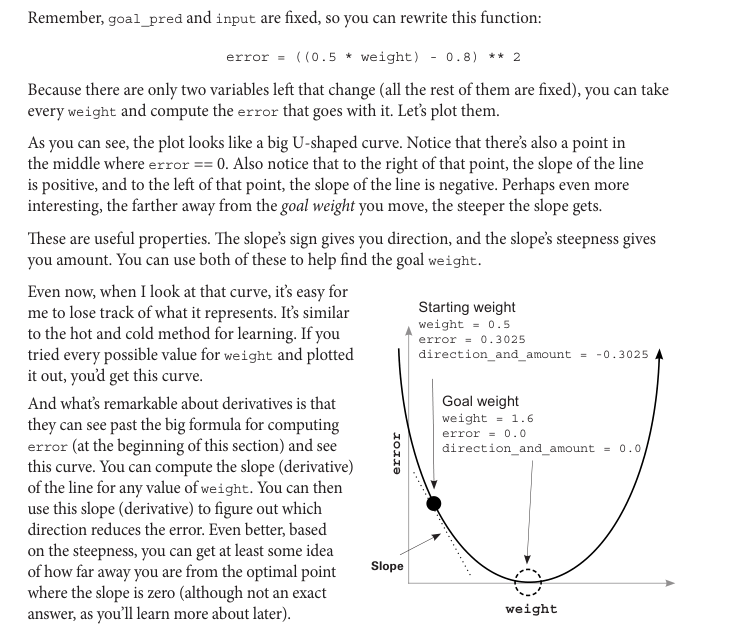

Plot hubungan weight dan error berbentuk kurva U. Ada titik tengah tempat `error == 0`. Di kanan titik tersebut, slope bernilai positif. Di kiri titik tersebut, slope bernilai negatif. Semakin jauh dari goal weight, slope semakin curam.

Tanda slope memberi arah. Kecuraman slope memberi jumlah. Keduanya dapat digunakan untuk membantu menemukan goal weight.

## What you really need to know

Dengan derivatives, dua variabel apa pun dalam formula dapat dipilih untuk mengetahui bagaimana keduanya berinteraksi.

Untuk function apa pun, dua variabel dapat dipilih dan diplot pada grafik x-y. Dua variabel juga dapat dipilih untuk menghitung seberapa besar satu variabel berubah ketika variabel lain diubah.

Neural network adalah kumpulan weights yang digunakan untuk menghitung error function. Untuk error function apa pun, hubungan antara setiap weight dan final error dapat dihitung. Dengan informasi itu, setiap weight dapat diubah untuk mengurangi error menuju 0.

## What you don’t really need to know

Yang tidak benar-benar dibutuhkan di sini adalah seluruh detail kalkulus.

Yang penting adalah memahami arti derivative: hubungan antara dua variabel dalam sebuah function, sehingga diketahui seberapa besar satu variabel berubah ketika variabel lain diubah. Derivative adalah sensitivitas antara dua variabel.

Sensitivitas dapat positif ketika variabel bergerak bersama, negatif ketika bergerak berlawanan, atau nol ketika satu variabel tetap walaupun variabel lain berubah.

## How to use a derivative to learn

`weight_delta` adalah derivative.

`error` mengukur seberapa jauh prediction meleset. Derivative mendefinisikan hubungan antara setiap weight dan seberapa jauh prediction meleset. Dengan kata lain, derivative menunjukkan seberapa besar perubahan weight berkontribusi pada error.

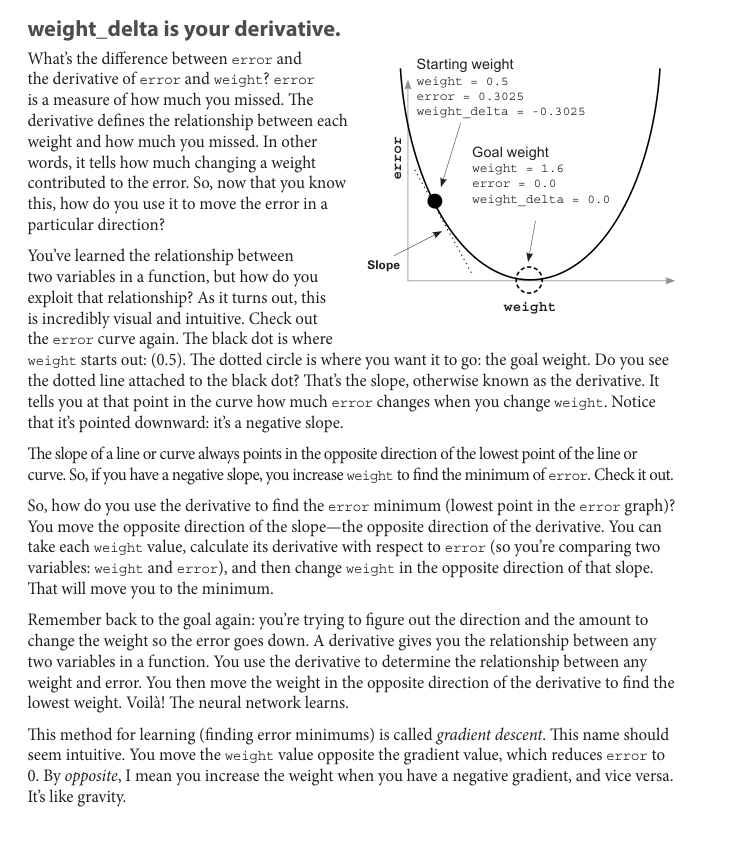

Untuk menemukan minimum error, weight digerakkan ke arah berlawanan dari slope atau derivative. Jika slope negatif, weight dinaikkan. Jika slope positif, weight diturunkan.

Metode untuk menemukan minimum error ini disebut **gradient descent**. Weight digerakkan berlawanan arah dengan gradient agar error berkurang menuju 0.

## Look familiar?

Kode gradient descent yang sudah digunakan sebelumnya memakai `weight_delta` sebagai derivative.

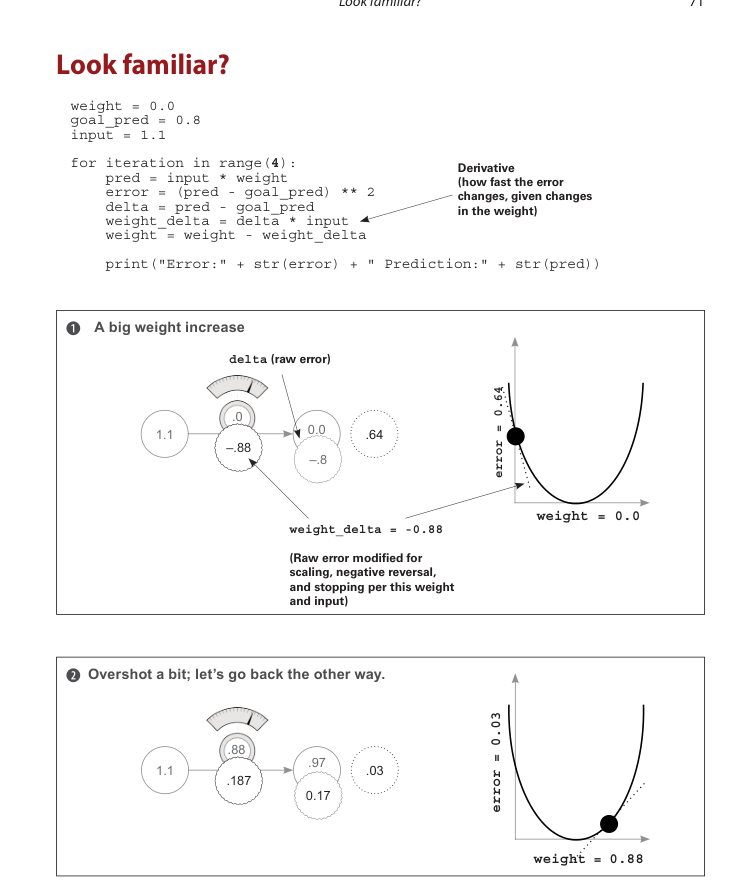

In [10]:
weight = 0.0
goal_pred = 0.8
input = 1.1

for iteration in range(4):
  pred = input * weight
  error = (pred - goal_pred) ** 2
  delta = pred - goal_pred
  weight_delta = delta * input
  weight = weight - weight_delta

  print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.6400000000000001 Prediction:0.0
Error:0.02822400000000005 Prediction:0.9680000000000002
Error:0.0012446784000000064 Prediction:0.76472
Error:5.4890317439999896e-05 Prediction:0.8074088


## Breaking gradient descent

Gradient descent dapat dibuat gagal dengan beberapa kombinasi nilai awal, `goal_pred`, dan `input`.

Kode berikut masih bekerja ketika `input = 0.5`.

In [11]:
weight = 0.5
goal_pred = 0.8
input = 0.5

for iteration in range(20):
  pred = input * weight
  error = (pred - goal_pred) ** 2
  delta = pred - goal_pred
  weight_delta = input * delta
  weight = weight - weight_delta

  print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.30250000000000005 Prediction:0.25
Error:0.17015625000000004 Prediction:0.3875
Error:0.095712890625 Prediction:0.49062500000000003
Error:0.05383850097656251 Prediction:0.56796875
Error:0.03028415679931642 Prediction:0.6259765625
Error:0.0170348381996155 Prediction:0.669482421875
Error:0.00958209648728372 Prediction:0.70211181640625
Error:0.005389929274097089 Prediction:0.7265838623046875
Error:0.0030318352166796153 Prediction:0.7449378967285156
Error:0.0017054073093822882 Prediction:0.7587034225463867
Error:0.0009592916115275371 Prediction:0.76902756690979
Error:0.0005396015314842384 Prediction:0.7767706751823426
Error:0.000303525861459885 Prediction:0.7825780063867569
Error:0.00017073329707118678 Prediction:0.7869335047900676
Error:9.603747960254256e-05 Prediction:0.7902001285925507
Error:5.402108227642978e-05 Prediction:0.7926500964444131
Error:3.038685878049206e-05 Prediction:0.7944875723333098
Error:1.7092608064027242e-05 Prediction:0.7958656792499823
Error:9.614592036015323

Ketika `input = 2`, prediction dapat meledak dan bergerak semakin jauh dari target.

In [12]:
weight = 0.5
goal_pred = 0.8
input = 2

for iteration in range(20):
  pred = input * weight
  error = (pred - goal_pred) ** 2
  delta = pred - goal_pred
  weight_delta = input * delta
  weight = weight - weight_delta

  print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.03999999999999998 Prediction:1.0
Error:0.3599999999999998 Prediction:0.20000000000000018
Error:3.2399999999999984 Prediction:2.5999999999999996
Error:29.159999999999986 Prediction:-4.599999999999999
Error:262.4399999999999 Prediction:16.999999999999996
Error:2361.959999999998 Prediction:-47.79999999999998
Error:21257.639999999978 Prediction:146.59999999999994
Error:191318.75999999983 Prediction:-436.5999999999998
Error:1721868.839999999 Prediction:1312.9999999999995
Error:15496819.559999991 Prediction:-3935.799999999999
Error:139471376.03999993 Prediction:11810.599999999997
Error:1255242384.3599997 Prediction:-35428.59999999999
Error:11297181459.239996 Prediction:106288.99999999999
Error:101674633133.15994 Prediction:-318863.79999999993
Error:915071698198.4395 Prediction:956594.5999999997
Error:8235645283785.954 Prediction:-2869780.599999999
Error:74120807554073.56 Prediction:8609344.999999996
Error:667087267986662.1 Prediction:-25828031.799999986
Error:6003785411879960.0 Predi

## Visualizing the overcorrections

Ketika update terlalu besar, weight melewati titik target, lalu bergerak kembali ke arah sebaliknya dengan koreksi yang semakin besar.

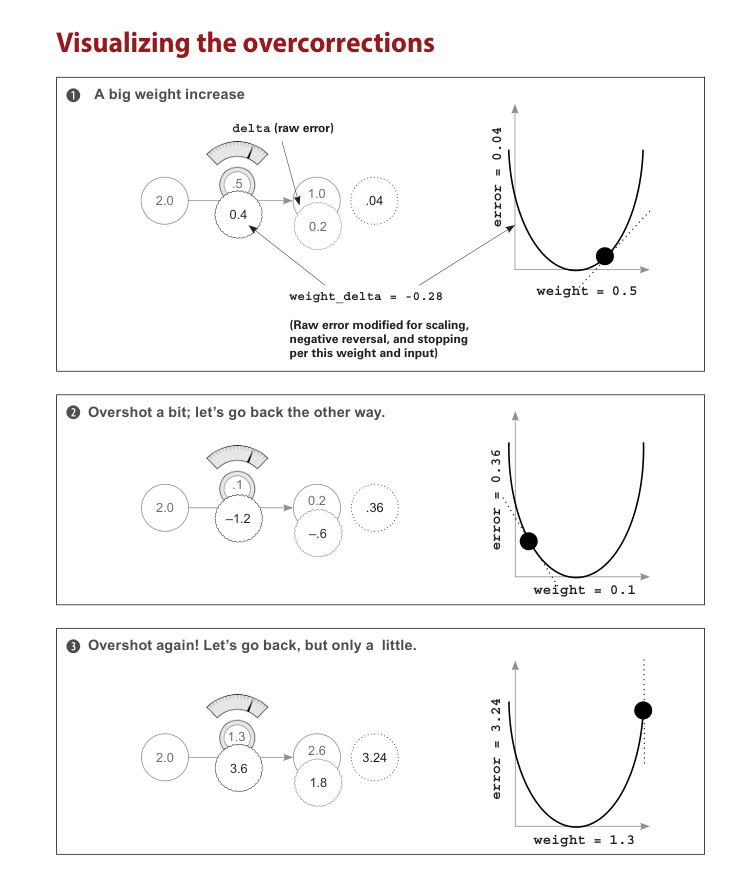

## Divergence

Kadang neural networks meledak nilainya.

Ledakan error terjadi karena input dibuat lebih besar. Update weight dihitung dengan:

`weight = weight - (input * (pred - goal_pred))`

Jika input cukup besar, update weight dapat menjadi besar walaupun error kecil. Ketika update weight besar dan error kecil, network overcorrects. Jika error baru menjadi lebih besar, network overcorrects lebih besar lagi. Fenomena ini disebut **divergence**.

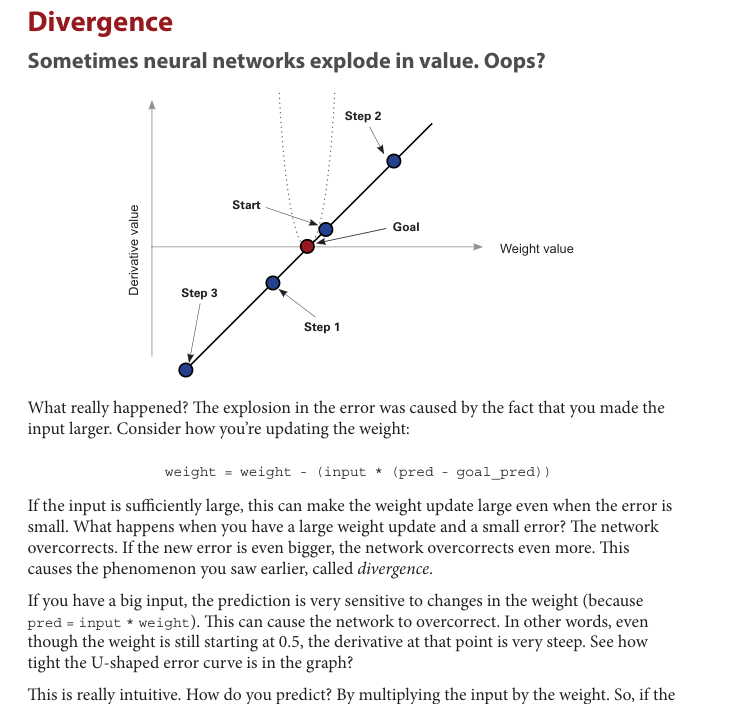

Jika input besar, prediction sangat sensitif terhadap perubahan weight karena `pred = input * weight`. Perubahan kecil pada weight dapat menyebabkan perubahan besar pada prediction. Artinya derivative menjadi besar.

## Introducing alpha

Alpha adalah cara paling sederhana untuk mencegah update weight yang overcorrect.

Masalah yang ingin diselesaikan adalah ketika input terlalu besar, update weight dapat terlalu besar. Gejalanya adalah derivative baru menjadi lebih besar daripada sebelumnya, walaupun tandanya berlawanan.

Solusinya adalah mengalikan update weight dengan pecahan agar lebih kecil. Angka ini biasanya berupa nilai real antara 0 dan 1, dan disebut **alpha**.

Menentukan alpha yang sesuai sering dilakukan dengan mencoba. Jika error diverging atau naik, alpha terlalu tinggi dan perlu dikurangi. Jika learning terlalu lambat, alpha terlalu rendah dan perlu dinaikkan.

## Alpha in code

Sebelumnya, weight diperbarui dengan:

`weight = weight - derivative`

Dengan alpha, update menjadi:

`weight = weight - (alpha * derivative)`

Jika alpha kecil, update weight berkurang sehingga overshoot dapat dicegah.

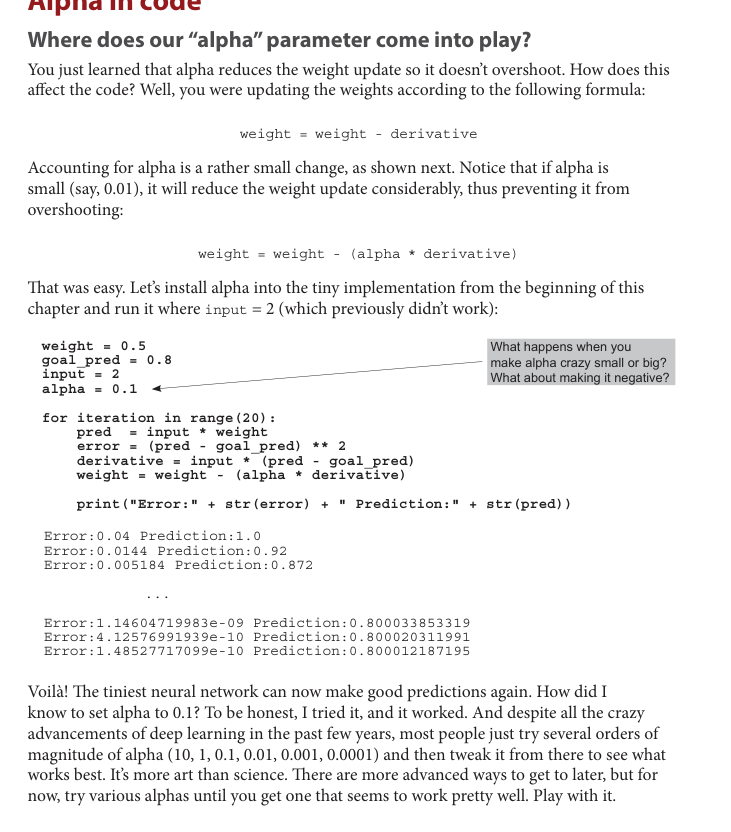

In [13]:
weight = 0.5
goal_pred = 0.8
input = 2
alpha = 0.1

for iteration in range(20):
  pred = input * weight
  error = (pred - goal_pred) ** 2
  derivative = input * (pred - goal_pred)
  weight = weight - (alpha * derivative)

  print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.03999999999999998 Prediction:1.0
Error:0.0144 Prediction:0.92
Error:0.005183999999999993 Prediction:0.872
Error:0.0018662400000000014 Prediction:0.8432000000000001
Error:0.0006718464000000028 Prediction:0.8259200000000001
Error:0.00024186470400000033 Prediction:0.815552
Error:8.70712934399997e-05 Prediction:0.8093312
Error:3.134566563839939e-05 Prediction:0.80559872
Error:1.1284439629823931e-05 Prediction:0.803359232
Error:4.062398266736526e-06 Prediction:0.8020155392
Error:1.4624633760252567e-06 Prediction:0.8012093235200001
Error:5.264868153690924e-07 Prediction:0.8007255941120001
Error:1.8953525353291194e-07 Prediction:0.8004353564672001
Error:6.82326912718715e-08 Prediction:0.8002612138803201
Error:2.456376885786678e-08 Prediction:0.8001567283281921
Error:8.842956788836216e-09 Prediction:0.8000940369969153
Error:3.1834644439835434e-09 Prediction:0.8000564221981492
Error:1.1460471998340758e-09 Prediction:0.8000338533188895
Error:4.125769919393652e-10 Prediction:0.80002031199

Pertanyaan pada bagian ini adalah apa yang terjadi jika alpha dibuat sangat kecil, sangat besar, atau negatif. Kode berikut menjalankan percobaan tersebut.

In [14]:
def run_alpha_experiment(alpha, iterations=10):
  weight = 0.5
  goal_pred = 0.8
  input = 2

  print("Alpha:", alpha)

  for iteration in range(iterations):
    pred = input * weight
    error = (pred - goal_pred) ** 2
    derivative = input * (pred - goal_pred)
    weight = weight - (alpha * derivative)

    print("Error:" + str(error) + " Prediction:" + str(pred))

  print()

run_alpha_experiment(alpha=0.0001)
run_alpha_experiment(alpha=10)
run_alpha_experiment(alpha=-0.1)

Alpha: 0.0001
Error:0.03999999999999998 Prediction:1.0
Error:0.03996800639999999 Prediction:0.99992
Error:0.03993603838976102 Prediction:0.999840032
Error:0.03990409594881536 Prediction:0.9997600959872001
Error:0.03987217905671167 Prediction:0.9996801919488052
Error:0.03984028769301495 Prediction:0.9996003198720257
Error:0.039808421837306575 Prediction:0.9995204797440769
Error:0.039776581469184204 Prediction:0.9994406715521792
Error:0.03974476656826188 Prediction:0.9993608952835583
Error:0.03971297711416993 Prediction:0.9992811509254449

Alpha: 10
Error:0.03999999999999998 Prediction:1.0
Error:60.83999999999997 Prediction:-6.999999999999998
Error:92537.63999999996 Prediction:304.99999999999994
Error:140749750.4399999 Prediction:-11862.999999999996
Error:214080370419.23984 Prediction:462688.9999999998
Error:325616243407663.8 Prediction:-18044838.999999993
Error:4.952623062230568e+17 Prediction:703748752.9999998
Error:7.532939677652693e+20 Prediction:-27446201334.999992
Error:1.145760124

## Memorizing

Latihan pada bagian ini meminta kode dari bagian sebelumnya dibuat ulang. Kode berikut adalah implementasi gradient descent dengan alpha.

In [15]:
weight = 0.5
goal_pred = 0.8
input = 2
alpha = 0.1

for iteration in range(20):
  pred = input * weight
  error = (pred - goal_pred) ** 2
  derivative = input * (pred - goal_pred)
  weight = weight - (alpha * derivative)

  print("Error:" + str(error) + " Prediction:" + str(pred))

Error:0.03999999999999998 Prediction:1.0
Error:0.0144 Prediction:0.92
Error:0.005183999999999993 Prediction:0.872
Error:0.0018662400000000014 Prediction:0.8432000000000001
Error:0.0006718464000000028 Prediction:0.8259200000000001
Error:0.00024186470400000033 Prediction:0.815552
Error:8.70712934399997e-05 Prediction:0.8093312
Error:3.134566563839939e-05 Prediction:0.80559872
Error:1.1284439629823931e-05 Prediction:0.803359232
Error:4.062398266736526e-06 Prediction:0.8020155392
Error:1.4624633760252567e-06 Prediction:0.8012093235200001
Error:5.264868153690924e-07 Prediction:0.8007255941120001
Error:1.8953525353291194e-07 Prediction:0.8004353564672001
Error:6.82326912718715e-08 Prediction:0.8002612138803201
Error:2.456376885786678e-08 Prediction:0.8001567283281921
Error:8.842956788836216e-09 Prediction:0.8000940369969153
Error:3.1834644439835434e-09 Prediction:0.8000564221981492
Error:1.1460471998340758e-09 Prediction:0.8000338533188895
Error:4.125769919393652e-10 Prediction:0.80002031199

## Summary

Chapter ini membahas bagaimana neural network belajar dengan menurunkan error.

Compare digunakan untuk mengukur seberapa jauh prediction meleset. Learn digunakan untuk mengubah weight agar error berkurang. Hot and cold learning menunjukkan bentuk learning paling sederhana, tetapi tidak efisien dan bergantung pada `step_amount`.

Gradient descent menggunakan derivative untuk menentukan arah dan jumlah perubahan weight. Weight digerakkan berlawanan arah dari derivative agar error turun. Ketika update weight terlalu besar, network dapat mengalami divergence. Alpha digunakan untuk mengecilkan update weight dan membantu mencegah overshoot.